# Peak Firing Rate Distribution

This notebook checks whether saved ratemaps contain very large firing-rate values.

The main statistic is the **session-pooled peak firing rate**. For each saved `*_rmap.npz` session and each neuron, we first pool spike counts and dwell across all laps, compute an all-session spatial firing-rate map, and then take the peak across position bins.

Raw single-trial/bin peaks are also computed, but only as diagnostics. Those values can easily hit 1000 Hz when one spike falls into a bin with 1 ms of dwell, so they should not be interpreted as stable firing-rate peaks.

Finally, we merge the canonical `cell_classification_table.csv` and plot distributions separately for pyramidal cells and interneurons.

In [75]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src" / "placefields").is_dir():
    repo_root = repo_root.parent
if not (repo_root / "src" / "placefields").is_dir():
    raise RuntimeError("Could not find repository root containing src/placefields")

RATEMAP_ROOT = repo_root / "results" / "ratemap" / "ratemap__smooth_2p8__xrem_10__minspeed_2__mindwell_0p05__20260622_122853"
CLASSIFICATION_TABLE = (
    repo_root
    / "results"
    / "type_u_comparison_valero_feats_3"
    / "cell_classification_table.csv"
)

# Use pred_type for the current GMM classification. Change to "u_type" to use the legacy allcel label.
CELL_CLASS_COLUMN = "pred_type"
CELL_TYPES = ("pyramidal", "interneuron")
MIN_POOLED_DWELL_S = 0.10

RATEMAP_ROOT, CLASSIFICATION_TABLE

(WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass/results/ratemap/ratemap__smooth_2p8__xrem_10__minspeed_2__mindwell_0p05__20260622_122853'),
 WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass/results/type_u_comparison_valero_feats_3/cell_classification_table.csv'))

## Find One Ratemap Per Session

`results/ratemap` may contain older direct outputs and newer run-subdirectory outputs. To avoid double-counting, this cell scans all `*_rmap.npz` files and keeps the newest file for each `session_id`.

In [76]:
def session_id_from_rmap_path(path: Path) -> str:
    name = path.name
    suffix = "_rmap.npz"
    if not name.endswith(suffix):
        raise ValueError(f"Unexpected ratemap filename: {path}")
    return name[: -len(suffix)]


def choose_newest_rmap_per_session(root: Path) -> list[Path]:
    paths = sorted(root.rglob("*_rmap.npz"))
    by_session: dict[str, Path] = {}
    for path in paths:
        session_id = session_id_from_rmap_path(path)
        current = by_session.get(session_id)
        if current is None:
            by_session[session_id] = path
            continue
        current_key = (current.stat().st_mtime, str(current))
        path_key = (path.stat().st_mtime, str(path))
        if path_key > current_key:
            by_session[session_id] = path
    return [by_session[k] for k in sorted(by_session)]


all_rmap_paths = sorted(RATEMAP_ROOT.rglob("*_rmap.npz"))
rmap_paths = choose_newest_rmap_per_session(RATEMAP_ROOT)

rmap_index_df = pd.DataFrame(
    [
        {
            "session_id": session_id_from_rmap_path(path),
            "rmap_path": str(path.relative_to(repo_root)),
            "last_modified": pd.Timestamp(path.stat().st_mtime, unit="s"),
        }
        for path in rmap_paths
    ]
)

print(f"Found {len(all_rmap_paths)} ratemap files.")
print(f"Using {len(rmap_paths)} unique sessions after duplicate-session filtering.")
display(rmap_index_df.head())

Found 66 ratemap files.
Using 66 unique sessions after duplicate-session filtering.


,session_id,rmap_path,last_modified
0,VS100_2024-11-03_14-40-11,results\ratemap\ratemap__smooth_2p8__xrem_10__...,2026-06-22 10:28:59.577021599
1,VS100_2024-11-04_15-23-28,results\ratemap\ratemap__smooth_2p8__xrem_10__...,2026-06-22 10:29:04.686657667
2,VS101_2024-11-04_16-46-04,results\ratemap\ratemap__smooth_2p8__xrem_10__...,2026-06-22 10:29:07.460424662
3,VS101_2024-11-05_17-44-14,results\ratemap\ratemap__smooth_2p8__xrem_10__...,2026-06-22 10:29:43.802491903
4,VS102_2024-11-05_18-59-31,results\ratemap\ratemap__smooth_2p8__xrem_10__...,2026-06-22 10:30:02.340219021


## Compute Peak Firing Rate Per Neuron

For each neuron, the main peak is computed after pooling counts and dwell across all laps. We also keep the raw single-trial/bin maximum as a diagnostic because it can expose tiny-dwell artifacts.

In [77]:
def decode_meta_json(z: np.lib.npyio.NpzFile) -> dict:
    if "meta_json" not in z.files:
        return {}
    raw = z["meta_json"].tobytes().decode("utf-8", errors="ignore")
    meta = json.loads(raw)
    return meta if isinstance(meta, dict) else {}


def max_or_nan(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=np.float64)
    valid = np.isfinite(values)
    if not np.any(valid):
        return np.nan
    return float(np.max(values[valid]))


def peak_per_cell(rate_utx: np.ndarray) -> np.ndarray:
    rate = np.asarray(rate_utx, dtype=np.float64)
    if rate.ndim != 3:
        raise ValueError(f"Expected rate tensor cell x trial x bin, got shape {rate.shape}")
    flat = np.where(np.isfinite(rate), rate, -np.inf).reshape(rate.shape[0], -1)
    peak = flat.max(axis=1)
    peak[~np.isfinite(peak)] = np.nan
    return peak


def pooled_peak_per_cell(counts_utx: np.ndarray, dwell_tx_x: np.ndarray, *, min_dwell_s: float = 0.0) -> np.ndarray:
    counts = np.asarray(counts_utx, dtype=np.float64)
    dwell = np.asarray(dwell_tx_x, dtype=np.float64)
    if counts.ndim != 3:
        raise ValueError(f"Expected counts tensor cell x trial x bin, got shape {counts.shape}")
    if dwell.shape != counts.shape[1:]:
        raise ValueError(f"Dwell shape {dwell.shape} does not match trial/bin shape {counts.shape[1:]}")

    pooled_counts = np.nansum(counts, axis=1)
    pooled_dwell = np.nansum(dwell, axis=0)
    rate = np.divide(
        pooled_counts,
        pooled_dwell[None, :],
        out=np.full_like(pooled_counts, np.nan, dtype=np.float64),
        where=pooled_dwell[None, :] > 0,
    )
    if min_dwell_s > 0:
        rate[:, pooled_dwell < float(min_dwell_s)] = np.nan
    return np.array([max_or_nan(row) for row in rate], dtype=np.float64)


rows = []
failures = []

for rmap_path in rmap_paths:
    try:
        with np.load(rmap_path, allow_pickle=False) as z:
            meta = decode_meta_json(z)
            session_id = str(meta.get("session_id") or session_id_from_rmap_path(rmap_path))
            cell_ids = np.asarray(z["cell_ids"], dtype=np.int64).ravel()
            fr_raw = np.asarray(z["rmap__fr_tx_ux"], dtype=np.float64)
            fr_smoothed = np.asarray(z["rmap__fr_s_tx_ux"], dtype=np.float64)
            counts_raw = np.asarray(z["rmap__nbspk_tx_ux"], dtype=np.float64)
            dwell_raw = np.asarray(z["rmap__dwell_tx_x"], dtype=np.float64)
            counts_smoothed = np.asarray(z["rmap__nbspk_s_tx_ux"], dtype=np.float64)
            dwell_smoothed = np.asarray(z["rmap__dwell_s_tx_x"], dtype=np.float64)

        peak_raw = peak_per_cell(fr_raw)
        peak_smoothed = peak_per_cell(fr_smoothed)
        peak_raw_pooled = pooled_peak_per_cell(counts_raw, dwell_raw, min_dwell_s=MIN_POOLED_DWELL_S)
        peak_smoothed_pooled = pooled_peak_per_cell(counts_smoothed, dwell_smoothed, min_dwell_s=MIN_POOLED_DWELL_S)
        n_trials = int(fr_raw.shape[1])
        n_bins = int(fr_raw.shape[2])

        for cell_id, raw_hz, smoothed_hz, raw_pooled_hz, smoothed_pooled_hz in zip(
            cell_ids,
            peak_raw,
            peak_smoothed,
            peak_raw_pooled,
            peak_smoothed_pooled,
        ):
            rows.append(
                {
                    "session_id": session_id,
                    "cell_id": int(cell_id),
                    "peak_fr_raw_pooled_hz": float(raw_pooled_hz) if np.isfinite(raw_pooled_hz) else np.nan,
                    "peak_fr_smoothed_pooled_hz": float(smoothed_pooled_hz) if np.isfinite(smoothed_pooled_hz) else np.nan,
                    "min_pooled_dwell_s": MIN_POOLED_DWELL_S,
                    "peak_fr_raw_hz": float(raw_hz) if np.isfinite(raw_hz) else np.nan,
                    "peak_fr_smoothed_hz": float(smoothed_hz) if np.isfinite(smoothed_hz) else np.nan,
                    "n_trials": n_trials,
                    "n_bins": n_bins,
                    "rmap_path": str(rmap_path.relative_to(repo_root)),
                    "run_id": meta.get("run_id", ""),
                    "smooth_sigma_bins": meta.get("smooth_sigma_bins", np.nan),
                    "xbin_rem": meta.get("xbin_rem", np.nan),
                    "min_speed": meta.get("min_speed", np.nan),
                }
            )

    except Exception as exc:
        failures.append({"rmap_path": str(rmap_path), "error": repr(exc)})

peak_df = pd.DataFrame(rows)
failure_df = pd.DataFrame(failures)

print(f"Computed peaks for {len(peak_df)} neurons from {peak_df['session_id'].nunique() if not peak_df.empty else 0} sessions.")
if not failure_df.empty:
    print(f"Failed to read {len(failure_df)} ratemap files.")
    display(failure_df.head())

display(peak_df.head())

Computed peaks for 1261 neurons from 66 sessions.


,session_id,cell_id,peak_fr_raw_pooled_hz,peak_fr_smoothed_pooled_hz,min_pooled_dwell_s,peak_fr_raw_hz,peak_fr_smoothed_hz,n_trials,n_bins,rmap_path,run_id,smooth_sigma_bins,xbin_rem,min_speed
0,VS100_2024-11-03_14-40-11,6,17.189080,12.789010,0.1,73.684211,25.204475,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0
1,VS100_2024-11-03_14-40-11,9,20.588235,16.386901,0.1,94.488189,55.027707,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0
2,VS100_2024-11-03_14-40-11,19,21.957574,14.321658,0.1,71.428571,36.749146,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0
3,VS100_2024-11-03_14-40-11,22,8.339376,5.211220,0.1,37.735849,18.294772,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0
4,VS100_2024-11-03_14-40-11,25,10.616785,7.687439,0.1,76.923077,35.963354,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0


## Merge Cell Classification

`pred_type` is the current GMM classification. `u_type` is the legacy allcel label, if the table has been regenerated with that column.

In [78]:
if CLASSIFICATION_TABLE.exists():
    class_df = pd.read_csv(CLASSIFICATION_TABLE)
    keep_cols = [
        col
        for col in [
            "session_id",
            "cell_id",
            "pred_type",
            "u_type",
            "p_pred_type",
            "Sure (P(pred_type) > 0.6)",
            "age_group",
        ]
        if col in class_df.columns
    ]
    class_df = class_df[keep_cols].copy()
    class_df["session_id"] = class_df["session_id"].astype(str)
    class_df["cell_id"] = pd.to_numeric(class_df["cell_id"], errors="coerce").astype("Int64")
    class_df = class_df.dropna(subset=["session_id", "cell_id"])
    class_df["cell_id"] = class_df["cell_id"].astype(np.int64)

    peak_df = peak_df.merge(class_df, on=["session_id", "cell_id"], how="left")
else:
    print(f"Classification table not found: {CLASSIFICATION_TABLE}")

if CELL_CLASS_COLUMN in peak_df.columns:
    peak_df["cell_group"] = peak_df[CELL_CLASS_COLUMN].astype("string").str.lower()
else:
    peak_df["cell_group"] = "unclassified"

peak_df["cell_group"] = peak_df["cell_group"].fillna("unclassified")

print(peak_df["cell_group"].value_counts(dropna=False))
display(peak_df.head())

cell_group
pyramidal       514
interneuron     493
unclassified    254
Name: count, dtype: Int64


,session_id,cell_id,peak_fr_raw_pooled_hz,peak_fr_smoothed_pooled_hz,min_pooled_dwell_s,peak_fr_raw_hz,peak_fr_smoothed_hz,n_trials,n_bins,rmap_path,run_id,smooth_sigma_bins,xbin_rem,min_speed,pred_type,u_type,p_pred_type,Sure (P(pred_type) > 0.6),age_group,cell_group
0,VS100_2024-11-03_14-40-11,6,17.189080,12.789010,0.1,73.684211,25.204475,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0,interneuron,interneuron,1.0,True,P16-18,interneuron
1,VS100_2024-11-03_14-40-11,9,20.588235,16.386901,0.1,94.488189,55.027707,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0,interneuron,interneuron,1.0,True,P16-18,interneuron
2,VS100_2024-11-03_14-40-11,19,21.957574,14.321658,0.1,71.428571,36.749146,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0,interneuron,interneuron,1.0,True,P16-18,interneuron
3,VS100_2024-11-03_14-40-11,22,8.339376,5.211220,0.1,37.735849,18.294772,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0,interneuron,interneuron,1.0,True,P16-18,interneuron
4,VS100_2024-11-03_14-40-11,25,10.616785,7.687439,0.1,76.923077,35.963354,21,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...,ratemap__smooth_2p8__xrem_10__minspeed_2__mind...,2.8,10,2.0,interneuron,interneuron,1.0,True,P16-18,interneuron


## Main Summary Tables

These tables use the session-pooled peaks. The raw single-trial/bin peaks are shown only as diagnostic columns.

In [79]:
summary_df = (
    peak_df.groupby("cell_group", dropna=False)
    .agg(
        n_neurons=("cell_id", "size"),
        n_sessions=("session_id", "nunique"),
        raw_pooled_median_hz=("peak_fr_raw_pooled_hz", "median"),
        raw_pooled_p95_hz=("peak_fr_raw_pooled_hz", lambda x: np.nanpercentile(x, 95)),
        raw_pooled_max_hz=("peak_fr_raw_pooled_hz", "max"),
        smoothed_pooled_median_hz=("peak_fr_smoothed_pooled_hz", "median"),
        smoothed_pooled_p95_hz=("peak_fr_smoothed_pooled_hz", lambda x: np.nanpercentile(x, 95)),
        smoothed_pooled_max_hz=("peak_fr_smoothed_pooled_hz", "max"),
        diagnostic_raw_trialbin_max_hz=("peak_fr_raw_hz", "max"),
        diagnostic_smoothed_trialbin_max_hz=("peak_fr_smoothed_hz", "max"),
    )
    .reset_index()
    .sort_values("n_neurons", ascending=False)
)

display(summary_df)

top_raw = peak_df.sort_values("peak_fr_raw_pooled_hz", ascending=False).head(20)
top_smoothed = peak_df.sort_values("peak_fr_smoothed_pooled_hz", ascending=False).head(20)

display(
    top_raw[
        [
            "session_id",
            "cell_id",
            "cell_group",
            "peak_fr_raw_pooled_hz",
            "peak_fr_smoothed_pooled_hz",
            "peak_fr_raw_hz",
            "peak_fr_smoothed_hz",
            "n_trials",
            "n_bins",
        ]
    ]
)
display(
    top_smoothed[
        [
            "session_id",
            "cell_id",
            "cell_group",
            "peak_fr_raw_pooled_hz",
            "peak_fr_smoothed_pooled_hz",
            "peak_fr_raw_hz",
            "peak_fr_smoothed_hz",
            "n_trials",
            "n_bins",
        ]
    ]
)

,cell_group,n_neurons,n_sessions,raw_pooled_median_hz,raw_pooled_p95_hz,raw_pooled_max_hz,smoothed_pooled_median_hz,smoothed_pooled_p95_hz,smoothed_pooled_max_hz,diagnostic_raw_trialbin_max_hz,diagnostic_smoothed_trialbin_max_hz
1,pyramidal,514,52,8.484318,52.327610,102.059925,5.161800,43.148350,82.634093,537.037037,182.181380
0,interneuron,493,55,12.791142,51.999651,107.779886,9.206833,43.411745,96.723069,301.587302,187.533326
2,unclassified,254,11,10.607707,58.034713,103.534304,6.519740,48.702962,87.506577,460.674157,227.342442


,session_id,cell_id,cell_group,peak_fr_raw_pooled_hz,peak_fr_smoothed_pooled_hz,peak_fr_raw_hz,peak_fr_smoothed_hz,n_trials,n_bins
759,VS57_2022-12-19_16-30-47,79,interneuron,107.779886,96.723069,301.587302,187.533326,32,80
438,VS11_2022-02-10_17-46-04,60,unclassified,103.534304,84.549041,226.804124,121.668099,50,80
467,VS125_2025-04-04_15-39-27,11,pyramidal,102.059925,82.634093,218.181818,182.181380,20,80
761,VS57_2022-12-19_16-30-47,118,interneuron,97.887020,95.034304,193.181818,149.857655,32,80
441,VS11_2022-02-10_17-46-04,76,unclassified,95.063025,87.506577,297.297297,227.342442,50,80
200,VS106_2024-11-12_14-55-21,40,unclassified,84.121453,73.194869,256.410256,147.942717,25,80
1010,VS68_2023-02-23_18-54-54,257,interneuron,82.753825,61.998087,223.684211,140.577070,20,80
867,VS65_2023-02-15_18-41-14,213,interneuron,82.373272,67.968186,168.341709,109.360856,20,80
491,VS125_2025-04-04_15-39-27,92,interneuron,81.597222,68.446926,157.894737,113.472266,20,80
357,VS116_2025-02-22_18-19-46,110,unclassified,80.327869,75.130383,243.243243,165.226704,36,80


,session_id,cell_id,cell_group,peak_fr_raw_pooled_hz,peak_fr_smoothed_pooled_hz,peak_fr_raw_hz,peak_fr_smoothed_hz,n_trials,n_bins
759,VS57_2022-12-19_16-30-47,79,interneuron,107.779886,96.723069,301.587302,187.533326,32,80
761,VS57_2022-12-19_16-30-47,118,interneuron,97.887020,95.034304,193.181818,149.857655,32,80
441,VS11_2022-02-10_17-46-04,76,unclassified,95.063025,87.506577,297.297297,227.342442,50,80
438,VS11_2022-02-10_17-46-04,60,unclassified,103.534304,84.549041,226.804124,121.668099,50,80
467,VS125_2025-04-04_15-39-27,11,pyramidal,102.059925,82.634093,218.181818,182.181380,20,80
357,VS116_2025-02-22_18-19-46,110,unclassified,80.327869,75.130383,243.243243,165.226704,36,80
533,VS12_2022-02-26_12-01-52,37,pyramidal,79.027976,73.866597,207.547170,114.706301,80,80
200,VS106_2024-11-12_14-55-21,40,unclassified,84.121453,73.194869,256.410256,147.942717,25,80
330,VS115_2025-01-13_16-51-03,74,interneuron,78.578579,71.241126,166.666667,92.281752,61,80
771,VS57_2022-12-19_16-30-47,217,interneuron,72.106262,68.729540,225.000000,127.619536,32,80


## Session-Pooled Histograms By Cell Type

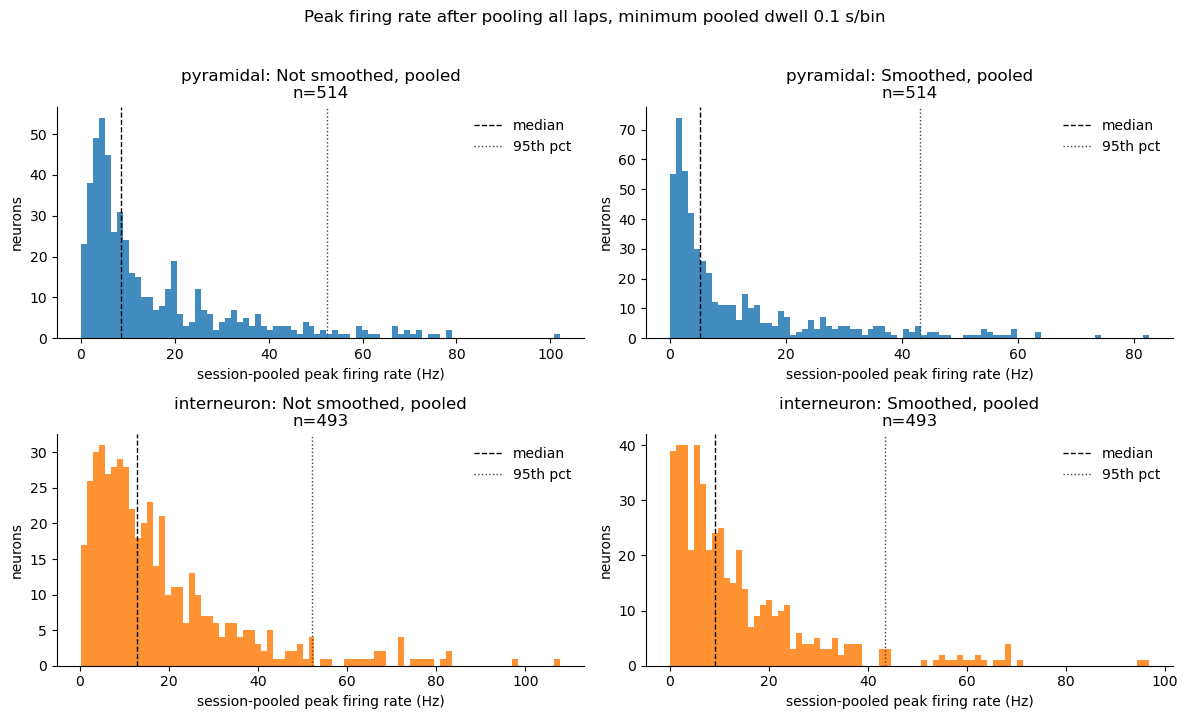

In [80]:
plot_df = peak_df[peak_df["cell_group"].isin(CELL_TYPES)].copy()

rate_specs = [
    ("peak_fr_raw_pooled_hz", "Not smoothed, pooled"),
    ("peak_fr_smoothed_pooled_hz", "Smoothed, pooled"),
]
colors = {"pyramidal": "tab:blue", "interneuron": "tab:orange"}
N_BINS = 80

fig, axes = plt.subplots(len(CELL_TYPES), len(rate_specs), figsize=(12, 7), squeeze=False)

for row, cell_type in enumerate(CELL_TYPES):
    for col, (rate_col, title) in enumerate(rate_specs):
        ax = axes[row, col]
        values = plot_df.loc[plot_df["cell_group"] == cell_type, rate_col].dropna().to_numpy()
        values = values[np.isfinite(values)]

        if values.size == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.hist(values, bins=N_BINS, color=colors.get(cell_type, "0.4"), alpha=0.85)
        ax.axvline(np.nanmedian(values), color="black", linestyle="--", linewidth=1, label="median")
        ax.axvline(np.nanpercentile(values, 95), color="0.25", linestyle=":", linewidth=1, label="95th pct")
        ax.set_title(f"{cell_type}: {title}\nn={values.size}")
        ax.set_xlabel("session-pooled peak firing rate (Hz)")
        ax.set_ylabel("neurons")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False)

fig.suptitle(
    f"Peak firing rate after pooling all laps, minimum pooled dwell {MIN_POOLED_DWELL_S:g} s/bin",
    y=1.02,
)
plt.tight_layout()

## Log-Scale Tail View

This view is often more useful for checking the tail of the session-pooled peak-rate distribution.

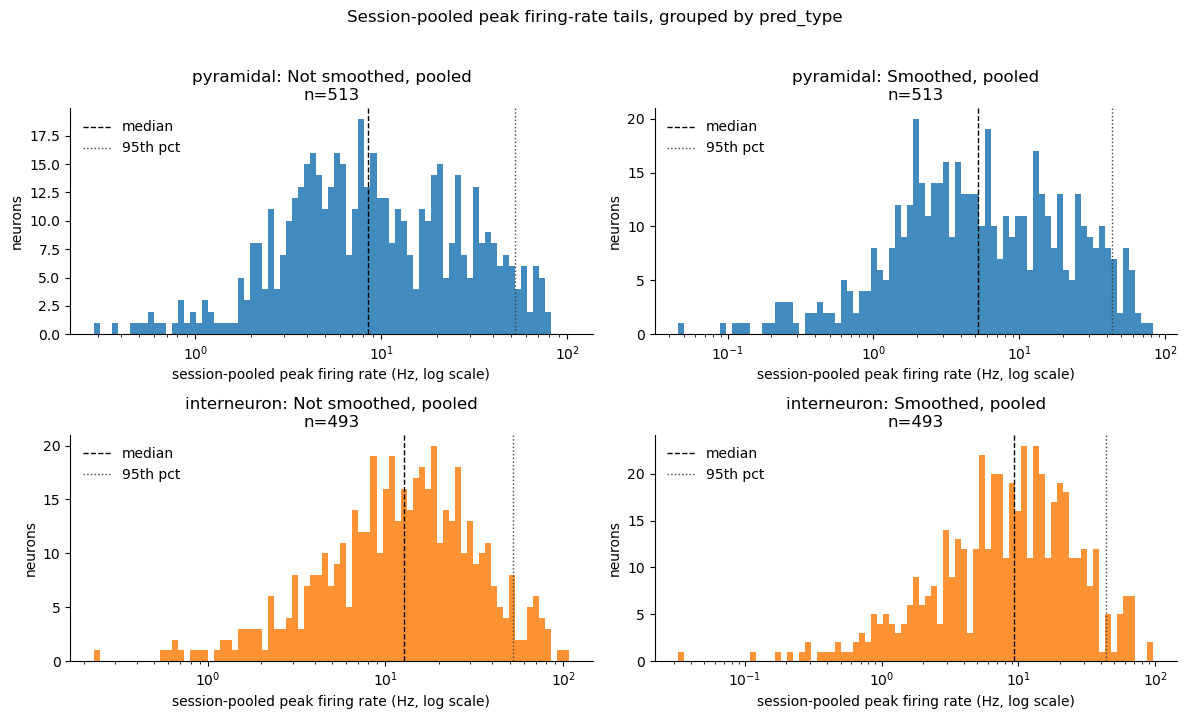

In [81]:
fig, axes = plt.subplots(len(CELL_TYPES), len(rate_specs), figsize=(12, 7), squeeze=False)

for row, cell_type in enumerate(CELL_TYPES):
    for col, (rate_col, title) in enumerate(rate_specs):
        ax = axes[row, col]
        values = plot_df.loc[plot_df["cell_group"] == cell_type, rate_col].dropna().to_numpy()
        values = values[np.isfinite(values) & (values > 0)]

        if values.size == 0:
            ax.text(0.5, 0.5, "no positive data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        lo = max(float(np.nanmin(values)), 1e-3)
        hi = float(np.nanmax(values))
        bins = np.logspace(np.log10(lo), np.log10(hi), N_BINS)

        ax.hist(values, bins=bins, color=colors.get(cell_type, "0.4"), alpha=0.85)
        ax.set_xscale("log")
        ax.axvline(np.nanmedian(values), color="black", linestyle="--", linewidth=1, label="median")
        ax.axvline(np.nanpercentile(values, 95), color="0.25", linestyle=":", linewidth=1, label="95th pct")
        ax.set_title(f"{cell_type}: {title}\nn={values.size}")
        ax.set_xlabel("session-pooled peak firing rate (Hz, log scale)")
        ax.set_ylabel("neurons")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False)

fig.suptitle(f"Session-pooled peak firing-rate tails, grouped by {CELL_CLASS_COLUMN}", y=1.02)
plt.tight_layout()

## Non-Pooled Session Max Histograms

These are the original peak-rate histograms: for each neuron, take the maximum firing-rate value across all trials and spatial bins in the session. This is useful as a diagnostic for tiny-dwell artifacts, but it is more sensitive to single trial/bin outliers than the pooled version above.

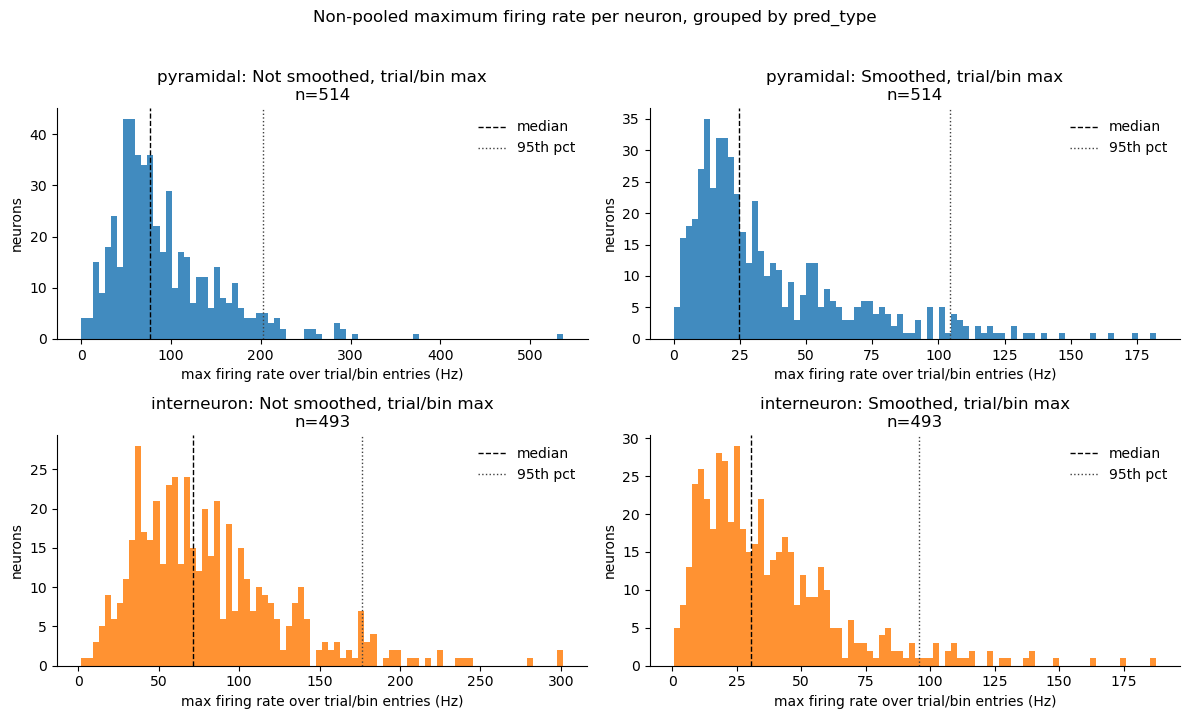

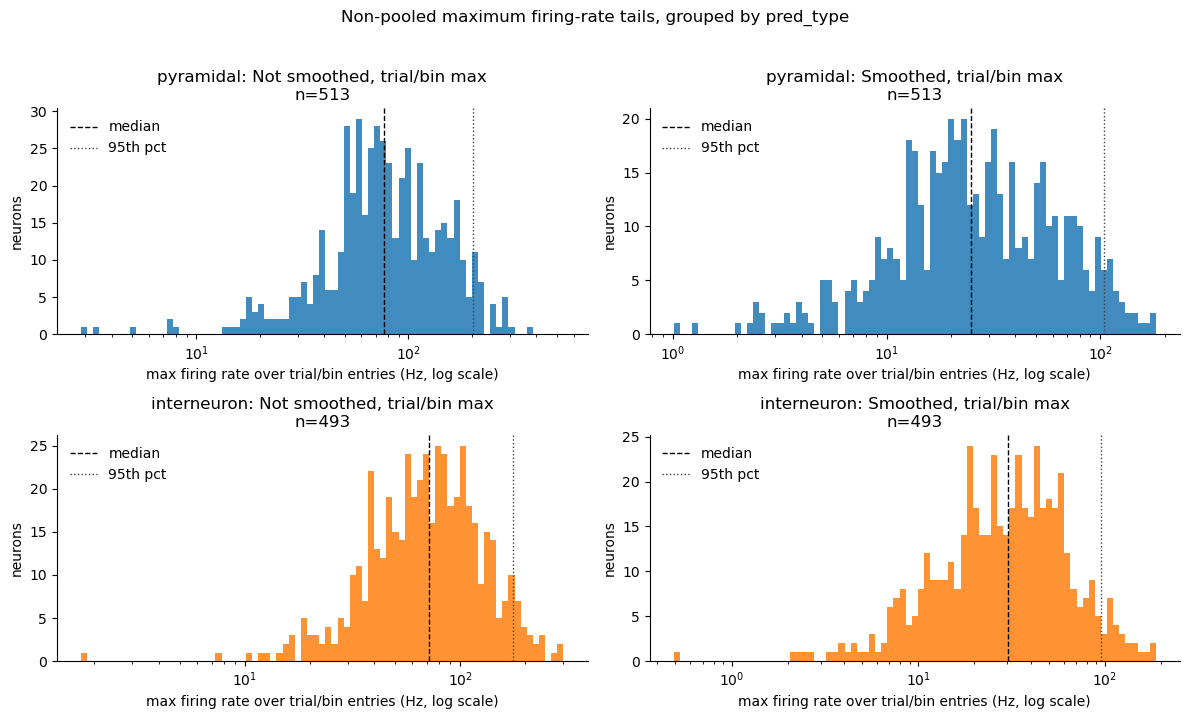

In [82]:
trial_peak_specs = [
    ("peak_fr_raw_hz", "Not smoothed, trial/bin max"),
    ("peak_fr_smoothed_hz", "Smoothed, trial/bin max"),
]

fig, axes = plt.subplots(len(CELL_TYPES), len(trial_peak_specs), figsize=(12, 7), squeeze=False)

for row, cell_type in enumerate(CELL_TYPES):
    for col, (rate_col, title) in enumerate(trial_peak_specs):
        ax = axes[row, col]
        values = plot_df.loc[plot_df["cell_group"] == cell_type, rate_col].dropna().to_numpy()
        values = values[np.isfinite(values)]

        if values.size == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.hist(values, bins=N_BINS, color=colors.get(cell_type, "0.4"), alpha=0.85)
        ax.axvline(np.nanmedian(values), color="black", linestyle="--", linewidth=1, label="median")
        ax.axvline(np.nanpercentile(values, 95), color="0.25", linestyle=":", linewidth=1, label="95th pct")
        ax.set_title(f"{cell_type}: {title}\nn={values.size}")
        ax.set_xlabel("max firing rate over trial/bin entries (Hz)")
        ax.set_ylabel("neurons")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False)

fig.suptitle(f"Non-pooled maximum firing rate per neuron, grouped by {CELL_CLASS_COLUMN}", y=1.02)
plt.tight_layout()

fig, axes = plt.subplots(len(CELL_TYPES), len(trial_peak_specs), figsize=(12, 7), squeeze=False)

for row, cell_type in enumerate(CELL_TYPES):
    for col, (rate_col, title) in enumerate(trial_peak_specs):
        ax = axes[row, col]
        values = plot_df.loc[plot_df["cell_group"] == cell_type, rate_col].dropna().to_numpy()
        values = values[np.isfinite(values) & (values > 0)]

        if values.size == 0:
            ax.text(0.5, 0.5, "no positive data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        lo = max(float(np.nanmin(values)), 1e-3)
        hi = float(np.nanmax(values))
        bins = np.logspace(np.log10(lo), np.log10(hi), N_BINS)

        ax.hist(values, bins=bins, color=colors.get(cell_type, "0.4"), alpha=0.85)
        ax.set_xscale("log")
        ax.axvline(np.nanmedian(values), color="black", linestyle="--", linewidth=1, label="median")
        ax.axvline(np.nanpercentile(values, 95), color="0.25", linestyle=":", linewidth=1, label="95th pct")
        ax.set_title(f"{cell_type}: {title}\nn={values.size}")
        ax.set_xlabel("max firing rate over trial/bin entries (Hz, log scale)")
        ax.set_ylabel("neurons")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False)

fig.suptitle(f"Non-pooled maximum firing-rate tails, grouped by {CELL_CLASS_COLUMN}", y=1.02)
plt.tight_layout()

## High Session-Pooled Rate Neurons

In [83]:
HIGH_POOLED_RATE_HZ = 100.0

high_rate_df = peak_df[
    (peak_df["peak_fr_raw_pooled_hz"] > HIGH_POOLED_RATE_HZ)
    | (peak_df["peak_fr_smoothed_pooled_hz"] > HIGH_POOLED_RATE_HZ)
].copy()

high_rate_df = high_rate_df.sort_values(
    ["peak_fr_raw_pooled_hz", "peak_fr_smoothed_pooled_hz"],
    ascending=[False, False],
)

print(f"Neurons with raw or smoothed session-pooled peak > {HIGH_POOLED_RATE_HZ:g} Hz: {len(high_rate_df)}")
display(
    high_rate_df[
        [
            "session_id",
            "cell_id",
            "cell_group",
            "peak_fr_raw_pooled_hz",
            "peak_fr_smoothed_pooled_hz",
            "peak_fr_raw_hz",
            "peak_fr_smoothed_hz",
            "n_trials",
            "n_bins",
            "rmap_path",
        ]
    ].head(50)
)

HIGH_TRIAL_RATE_HZ = HIGH_POOLED_RATE_HZ

high_trial_rate_df = peak_df[
    (peak_df["peak_fr_raw_hz"] > HIGH_TRIAL_RATE_HZ)
    | (peak_df["peak_fr_smoothed_hz"] > HIGH_TRIAL_RATE_HZ)
].copy()

high_trial_rate_df = high_trial_rate_df.sort_values(
    ["peak_fr_raw_hz", "peak_fr_smoothed_hz"],
    ascending=[False, False],
)

print(f"Neurons with raw or smoothed non-pooled trial/bin peak > {HIGH_TRIAL_RATE_HZ:g} Hz: {len(high_trial_rate_df)}")
display(
    high_trial_rate_df[
        [
            "session_id",
            "cell_id",
            "cell_group",
            "peak_fr_raw_hz",
            "peak_fr_smoothed_hz",
            "peak_fr_raw_pooled_hz",
            "peak_fr_smoothed_pooled_hz",
            "n_trials",
            "n_bins",
            "rmap_path",
        ]
    ].head(50)
)

Neurons with raw or smoothed session-pooled peak > 100 Hz: 3


,session_id,cell_id,cell_group,peak_fr_raw_pooled_hz,peak_fr_smoothed_pooled_hz,peak_fr_raw_hz,peak_fr_smoothed_hz,n_trials,n_bins,rmap_path
759,VS57_2022-12-19_16-30-47,79,interneuron,107.779886,96.723069,301.587302,187.533326,32,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...
438,VS11_2022-02-10_17-46-04,60,unclassified,103.534304,84.549041,226.804124,121.668099,50,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...
467,VS125_2025-04-04_15-39-27,11,pyramidal,102.059925,82.634093,218.181818,182.181380,20,80,results\ratemap\ratemap__smooth_2p8__xrem_10__...


## Dwell-Time Diagnostics

These histograms show the denominator behind the trial-level firing-rate maps. Raw `1000 Hz` values usually mean `1 spike / 0.001 s`, so the important question is how much mass the dwell distribution has near 1 ms. Dwell is a trial/bin property, so this section is not split by cell type.


,dwell_map,n_trial_bins,min_s,p01_s,p05_s,median_s,p95_s,max_s,pct_le_1ms,pct_le_5ms,pct_le_10ms,pct_le_50ms,pct_le_100ms
0,"raw dwell, visited trial/bin entries",171503,1.000000e-03,0.012000,0.022000,0.063000,0.312000,3.323000,0.000000,0.036734,0.453053,36.963785,71.828481
1,"smoothed dwell, positive trial/bin entries",171830,1.024317e-07,0.015597,0.023654,0.072406,0.245224,0.765955,0.050631,0.077402,0.104755,33.229937,64.292033


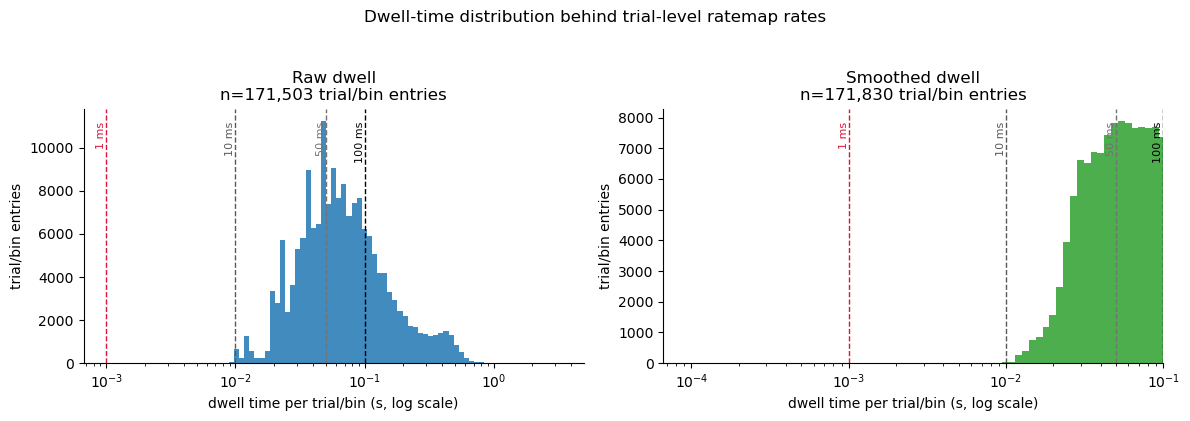

In [84]:
DWELL_EPS = np.finfo(np.float64).eps * 10
PLOT_MIN_DWELL_S = 1e-4
DWELL_THRESHOLDS_S = (0.001, 0.005, 0.010, 0.050, 0.100)


def finite_positive_dwell(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64).ravel()
    values = values[np.isfinite(values) & (values > DWELL_EPS)]
    return values


def dwell_summary_row(label: str, values: np.ndarray) -> dict:
    values = finite_positive_dwell(values)
    row = {
        "dwell_map": label,
        "n_trial_bins": int(values.size),
        "min_s": np.nan,
        "p01_s": np.nan,
        "p05_s": np.nan,
        "median_s": np.nan,
        "p95_s": np.nan,
        "max_s": np.nan,
    }
    for threshold_s in DWELL_THRESHOLDS_S:
        row[f"pct_le_{threshold_s * 1000:g}ms"] = np.nan

    if values.size == 0:
        return row

    row.update(
        {
            "min_s": float(np.nanmin(values)),
            "p01_s": float(np.nanpercentile(values, 1)),
            "p05_s": float(np.nanpercentile(values, 5)),
            "median_s": float(np.nanmedian(values)),
            "p95_s": float(np.nanpercentile(values, 95)),
            "max_s": float(np.nanmax(values)),
        }
    )
    for threshold_s in DWELL_THRESHOLDS_S:
        row[f"pct_le_{threshold_s * 1000:g}ms"] = float(
            100.0 * np.mean(values <= threshold_s + 1e-12)
        )
    return row


raw_dwell_chunks = []
smoothed_dwell_chunks = []

for rmap_path in rmap_paths:
    with np.load(rmap_path, allow_pickle=False) as z:
        raw_dwell_chunks.append(finite_positive_dwell(z["rmap__dwell_tx_x"]).astype(np.float32))
        smoothed_dwell_chunks.append(finite_positive_dwell(z["rmap__dwell_s_tx_x"]).astype(np.float32))

raw_dwell_s = np.concatenate(raw_dwell_chunks) if raw_dwell_chunks else np.array([], dtype=np.float32)
smoothed_dwell_s = (
    np.concatenate(smoothed_dwell_chunks) if smoothed_dwell_chunks else np.array([], dtype=np.float32)
)

dwell_summary_df = pd.DataFrame(
    [
        dwell_summary_row("raw dwell, visited trial/bin entries", raw_dwell_s),
        dwell_summary_row("smoothed dwell, positive trial/bin entries", smoothed_dwell_s),
    ]
)

display(dwell_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

dwell_specs = [
    (raw_dwell_s, "Raw dwell", "tab:blue"),
    (smoothed_dwell_s, "Smoothed dwell", "tab:green"),
]

for ax, (values, title, color) in zip(axes, dwell_specs):
    values = finite_positive_dwell(values)
    if values.size == 0:
        ax.text(0.5, 0.5, "no dwell data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    plot_values = values[values >= PLOT_MIN_DWELL_S]
    if plot_values.size == 0:
        plot_values = values

    lo = max(PLOT_MIN_DWELL_S, float(np.nanmin(plot_values)))
    hi = float(np.nanmax(plot_values))
    bins = np.logspace(np.log10(lo), np.log10(hi), 90)

    ax.hist(plot_values, bins=bins, color=color, alpha=0.85)
    ax.set_xscale("log")
    ax.set_title(f"{title}\nn={values.size:,} trial/bin entries")
    ax.set_xlabel("dwell time per trial/bin (s, log scale)")
    ax.set_ylabel("trial/bin entries")
    ax.spines[["top", "right"]].set_visible(False)

    for threshold_s, line_color in [
        (0.001, "crimson"),
        (0.010, "0.35"),
        (0.050, "0.45"),
        (0.100, "black"),
    ]:
        ax.axvline(threshold_s, color=line_color, linestyle="--", linewidth=1)
        ax.text(
            threshold_s,
            ax.get_ylim()[1] * 0.95,
            f"{threshold_s * 1000:g} ms",
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color=line_color,
        )
ax.set_xlim(right=0.1)
fig.suptitle("Dwell-time distribution behind trial-level ratemap rates", y=1.04)
plt.tight_layout()


## Inspect High Smoothed Trial Peaks

Use this table to check whether a suspicious trial-level peak comes from a very small dwell denominator, a true large number of spikes, or a classification mismatch between `pred_type` and `u_type`.

In [85]:
HIGH_SMOOTHED_TRIAL_HZ = 150.0

diagnostic_rows = []

for rmap_path in rmap_paths:
    with np.load(rmap_path, allow_pickle=False) as z:
        meta = decode_meta_json(z)
        session_id = str(meta.get("session_id") or session_id_from_rmap_path(rmap_path))
        cell_ids = np.asarray(z["cell_ids"], dtype=np.int64).ravel()
        fr_smoothed = np.asarray(z["rmap__fr_s_tx_ux"], dtype=np.float64)
        counts_raw = np.asarray(z["rmap__nbspk_tx_ux"], dtype=np.float64)
        dwell_raw = np.asarray(z["rmap__dwell_tx_x"], dtype=np.float64)
        counts_smoothed = np.asarray(z["rmap__nbspk_s_tx_ux"], dtype=np.float64)
        dwell_smoothed = np.asarray(z["rmap__dwell_s_tx_x"], dtype=np.float64)

    for u, cell_id in enumerate(cell_ids):
        cell_smoothed = fr_smoothed[u]
        if not np.any(np.isfinite(cell_smoothed)):
            continue
        peak_flat_idx = int(np.nanargmax(cell_smoothed))
        peak_trial, peak_bin = np.unravel_index(peak_flat_idx, cell_smoothed.shape)
        diagnostic_rows.append(
            {
                "session_id": session_id,
                "cell_id": int(cell_id),
                "peak_fr_smoothed_hz": float(cell_smoothed[peak_trial, peak_bin]),
                "peak_trial": int(peak_trial),
                "peak_bin": int(peak_bin),
                "smoothed_spikes_at_peak": float(counts_smoothed[u, peak_trial, peak_bin]),
                "smoothed_dwell_at_peak_s": float(dwell_smoothed[peak_trial, peak_bin]),
                "raw_spikes_at_peak": float(counts_raw[u, peak_trial, peak_bin]),
                "raw_dwell_at_peak_s": float(dwell_raw[peak_trial, peak_bin]),
            }
        )

diagnostic_df = pd.DataFrame(diagnostic_rows)
diagnostic_df = diagnostic_df.merge(
    peak_df[
        [
            "session_id",
            "cell_id",
            "cell_group",
            "pred_type",
            "u_type",
            "p_pred_type",
            "peak_fr_smoothed_pooled_hz",
        ]
    ],
    on=["session_id", "cell_id"],
    how="left",
)

suspicious_pyramidal_df = diagnostic_df[
    (diagnostic_df["cell_group"] == "pyramidal")
    & (diagnostic_df["peak_fr_smoothed_hz"] >= HIGH_SMOOTHED_TRIAL_HZ)
].sort_values("peak_fr_smoothed_hz", ascending=False)

print(
    f"Pyramidal neurons with smoothed trial-level peak >= {HIGH_SMOOTHED_TRIAL_HZ:g} Hz: "
    f"{len(suspicious_pyramidal_df)}"
)
display(
    suspicious_pyramidal_df[
        [
            "session_id",
            "cell_id",
            "pred_type",
            "u_type",
            "p_pred_type",
            "peak_fr_smoothed_hz",
            "peak_fr_smoothed_pooled_hz",
            "smoothed_spikes_at_peak",
            "smoothed_dwell_at_peak_s",
            "raw_spikes_at_peak",
            "raw_dwell_at_peak_s",
            "peak_trial",
            "peak_bin",
        ]
    ]
)


Pyramidal neurons with smoothed trial-level peak >= 150 Hz: 4


,session_id,cell_id,pred_type,u_type,p_pred_type,peak_fr_smoothed_hz,peak_fr_smoothed_pooled_hz,smoothed_spikes_at_peak,smoothed_dwell_at_peak_s,raw_spikes_at_peak,raw_dwell_at_peak_s,peak_trial,peak_bin
467,VS125_2025-04-04_15-39-27,11,pyramidal,interneuron,0.830540,182.181380,82.634093,46.473458,0.255094,128.0,0.624,17,47
385,VS118_2025-02-24_18-20-07,6,pyramidal,pyramidal,0.995771,174.572340,51.748859,48.514515,0.277905,49.0,0.276,4,79
1128,VS73_2023-03-21_19-53-41,121,pyramidal,pyramidal,0.995995,164.708145,63.480071,8.257011,0.050131,3.0,0.040,47,4
813,VS61_2023-02-08_16-55-37,101,pyramidal,pyramidal,0.904522,157.425179,35.342726,12.137951,0.077103,20.0,0.084,4,29
